# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Dini Arya Putri
- **Email:** diniarya135@gmail.com
- **ID Dicoding:** CDCC319D6X1000

## Menentukan Pertanyaan Bisnis



Dalam proyek analisis data ini, beberapa pertanyaan bisnis dirumuskan untuk memahami performa bisnis serta perilaku pelanggan secara lebih mendalam. Pertanyaan-pertanyaan ini akan menjadi dasar dalam proses eksplorasi dan analisis data.

1. Bagaimana performa penjualan dan revenue perusahaan dalam beberapa bulan terakhir?
2. Produk apa yang memiliki performa terbaik dan terburuk berdasarkan jumlah penjualan?
3. Bagaimana distribusi pelanggan berdasarkan wilayah (state)?
4. Bagaimana segmentasi pelanggan berdasarkan perilaku transaksi menggunakan analisis RFM (Recency, Frequency, Monetary)?
5. Bagaimana hubungan antara frekuensi transaksi dan total pengeluaran pelanggan?

## Import Semua Packages/Library yang Digunakan

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from babel.numbers import format_currency

# Konfigurasi visualisasi
sns.set(style='darkgrid')

## Data Wrangling

Tahap data wrangling dilakukan untuk mengumpulkan, menggabungkan, dan mempersiapkan data dari berbagai sumber agar siap digunakan dalam proses analisis.

Dataset yang digunakan terdiri dari beberapa tabel utama, yaitu:
- Customers
- Orders
- Order Items
- Products
- Product Category Translation

Seluruh dataset ini akan digabungkan menjadi satu dataframe utama untuk mempermudah analisis.

### Gathering Data

Pada tahap ini dilakukan proses pemuatan data dari masing-masing file CSV, kemudian dilakukan penggabungan antar tabel menggunakan operasi merge berdasarkan key yang sesuai.

In [45]:
# Memuat seluruh dataset yang relevan (Customers, Orders, Order_Items, Products, Translation)
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
translation_df = pd.read_csv("product_category_name_translation.csv")

# Menggabungkan data menjadi satu DataFrame (all_df)
orders_customers = pd.merge(left=orders_df, right=customers_df, how="left", on="customer_id")
order_items_prod = pd.merge(left=order_items_df, right=products_df, how="left", on="product_id")
order_items_prod = pd.merge(left=order_items_prod, right=translation_df, how="left", on="product_category_name")

all_df = pd.merge(left=orders_customers, right=order_items_prod, how="left", on="order_id")

# Menampilkan 5 baris pertama
all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


**Insight:**

- Proses integrasi data berhasil menggabungkan lima tabel utama menjadi satu master dataframe (`all_df`) yang komprehensif.
- Dataset yang telah digabungkan memungkinkan analisis multidimensi, seperti hubungan antara waktu transaksi, kategori produk, dan lokasi pelanggan.
- Dengan struktur data ini, analisis lanjutan seperti tren penjualan, segmentasi pelanggan (RFM), serta distribusi geografis dapat dilakukan secara lebih efektif.

### Assessing Data

In [46]:
print("Info Data Gabungan:")
all_df.info()

print("\nJumlah duplikasi pada data:", all_df.duplicated().sum())

print("\nJumlah missing values per kolom:")
print(all_df.isna().sum())

print("\nStatistik Deskriptif:")
display(all_df.describe())

print("\nJumlah nilai unik pada kolom kategorikal:")
categorical_cols = all_df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {all_df[col].nunique()} unique values")

print("\nCek Outlier pada Kolom Price:")
print("Min:", all_df['price'].min())
print("Max:", all_df['price'].max())

Info Data Gabungan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   customer_unique_id             113425 non-null  object 
 9   customer_zip_code_prefix       113425 non-null  int64  
 10  customer_city                  113425 non-null  object 
 11  customer_state                 113425 non-null  object 
 12  order_item

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,113425.000000,112650.000000,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000
mean,35102.472965,1.197834,120.653739,19.990320,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546
std,29864.919733,0.705124,183.633928,15.806405,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268
min,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,11250.000000,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,24320.000000,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,59020.000000,1.000000,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000



Jumlah nilai unik pada kolom kategorikal:
order_id: 99441 unique values
customer_id: 99441 unique values
order_status: 8 unique values
order_purchase_timestamp: 98875 unique values
order_approved_at: 90733 unique values
order_delivered_carrier_date: 81018 unique values
order_delivered_customer_date: 95664 unique values
order_estimated_delivery_date: 459 unique values
customer_unique_id: 96096 unique values
customer_city: 4119 unique values
customer_state: 27 unique values
product_id: 32951 unique values
seller_id: 3095 unique values
shipping_limit_date: 93318 unique values
product_category_name: 73 unique values
product_category_name_english: 71 unique values

Cek Outlier pada Kolom Price:
Min: 0.85
Max: 6735.0


**Insight:**

- Beberapa kolom yang merepresentasikan waktu seperti `order_purchase_timestamp` masih bertipe `object`, sehingga perlu dikonversi ke tipe `datetime` agar dapat digunakan dalam analisis berbasis waktu.

- Terdapat sejumlah missing values pada kolom `product_category_name_english`, yang berpotensi menyebabkan kategori produk tidak terdefinisi saat visualisasi atau analisis.

- Ditemukan kemungkinan duplikasi data yang perlu ditangani untuk menghindari bias dalam perhitungan metrik seperti jumlah transaksi dan revenue.

- Berdasarkan statistik deskriptif, terdapat variasi nilai pada fitur numerik seperti harga (`price`) yang cukup signifikan, mengindikasikan potensi adanya outlier yang perlu diperhatikan dalam analisis lanjutan.

- Kolom kategorikal memiliki jumlah nilai unik yang beragam, menunjukkan bahwa dataset memiliki kompleksitas tinggi dan cocok untuk analisis segmentasi pelanggan maupun produk.

- Rentang nilai pada kolom `price` cukup lebar, sehingga terdapat indikasi adanya outlier yang dapat mempengaruhi rata-rata dan distribusi data.

### Cleaning Data

In [47]:
# 1. Menghapus duplikasi data
all_df.drop_duplicates(inplace=True)

# 2. Mengubah tipe data kolom tanggal menjadi datetime
datetime_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    if col in all_df.columns:
        all_df[col] = pd.to_datetime(all_df[col], errors='coerce')

# 3. Memfilter hanya transaksi yang selesai (delivered)
all_df = all_df[all_df['order_status'] == 'delivered']

# 4. Menangani missing values pada kategori produk
all_df['product_category_name_english'].fillna('Unknown', inplace=True)

# 5. Menghapus missing values pada kolom penting (price)
all_df.dropna(subset=['price'], inplace=True)

# 6.Menangani missing pada freight_value
if 'freight_value' in all_df.columns:
    all_df['freight_value'].fillna(0, inplace=True)

# 7. Reset index setelah filtering
all_df.reset_index(drop=True, inplace=True)

# 8. Validasi hasil cleaning
print("Status Data Setelah Cleaning:")
all_df.info()

print("\nJumlah missing values setelah cleaning:")
print(all_df.isna().sum())

print("\nJumlah data setelah filter delivered:", len(all_df))
print("Rentang tanggal data:",
      all_df['order_purchase_timestamp'].min(),
      "sampai",
      all_df['order_purchase_timestamp'].max())

/tmp/ipykernel_3282/2543667869.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df['product_category_name_english'].fillna('Unknown', inplace=True)
/tmp/ipykernel_3282/2543667869.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

Status Data Setelah Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   customer_unique_id             110197 non-null  object        
 9   customer_zip_code_prefix       110197 non-null  int64         
 10  customer_city                  110197 

**Insight:**

- Seluruh kolom bertipe waktu berhasil dikonversi ke format `datetime`, sehingga memungkinkan analisis berbasis waktu seperti tren penjualan dan perhitungan recency pada RFM.

- Data difilter hanya pada transaksi dengan status `delivered`, untuk memastikan bahwa analisis hanya mencerminkan transaksi yang benar-benar selesai dan menghasilkan revenue aktual.

- Missing values pada kolom `product_category_name_english` telah ditangani dengan menggantinya menjadi "Unknown", sehingga tidak mengganggu proses agregasi dan visualisasi kategori produk.

- Missing values pada kolom `price` dihapus karena kolom ini merupakan komponen utama dalam perhitungan revenue, sehingga keberadaan nilai kosong dapat menyebabkan distorsi hasil analisis.

- Setelah proses cleaning, dataset menjadi lebih konsisten, bebas dari duplikasi, dan siap digunakan untuk analisis lanjutan seperti eksplorasi tren, segmentasi pelanggan, dan visualisasi interaktif.

- Data akhir mencakup rentang waktu yang cukup representatif untuk analisis tren dan perilaku pelanggan.

## Exploratory Data Analysis (EDA)

### EDA – TREN PENJUALAN

In [48]:
# Ekstraksi bulan
all_df['order_month'] = all_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Revenue per bulan
revenue_monthly = all_df.groupby('order_month').agg({
    'price': 'sum'
}).reset_index()

display(revenue_monthly.describe())

,price
count,23.000000
mean,574847.743913
std,337263.532856
min,10.900000
25%,349934.265000
50%,607399.670000
75%,862015.660000
max,987765.370000


### EDA – PRODUK TERLARIS

In [49]:
product_sales = all_df.groupby('product_category_name_english').agg({
    'order_item_id': 'count'
}).sort_values(by='order_item_id', ascending=False).reset_index()

display(product_sales.head(10))

,product_category_name_english,order_item_id
0,bed_bath_table,10953
1,health_beauty,9465
2,sports_leisure,8431
3,furniture_decor,8160
4,computers_accessories,7644
5,housewares,6795
6,watches_gifts,5859
7,telephony,4430
8,garden_tools,4268
9,auto,4140


### EDA – DISTRIBUSI CUSTOMER (GEOSPATIAL PROXY)

In [50]:
bystate_df = all_df.groupby(by="customer_state").customer_id.nunique().reset_index()
bystate_df.rename(columns={"customer_id": "customer_count"}, inplace=True)

display(bystate_df.sort_values(by="customer_count", ascending=False).head(10))

,customer_state,customer_count
25,SP,40501
18,RJ,12350
10,MG,11354
22,RS,5345
17,PR,4923
23,SC,3546
4,BA,3256
6,DF,2080
7,ES,1995
8,GO,1957


### EDA – HUBUNGAN FREQUENCY vs MONETARY

In [51]:
customer_spending = all_df.groupby('customer_unique_id').agg({
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

customer_spending.rename(columns={
    'order_id': 'frequency',
    'price': 'monetary'
}, inplace=True)

display(customer_spending.describe())

,frequency,monetary
count,93358.000000,93358.000000
mean,1.033420,141.621480
std,0.209097,215.694014
min,1.000000,0.850000
25%,1.000000,47.650000
50%,1.000000,89.730000
75%,1.000000,154.737500
max,15.000000,13440.000000


### EDA – DISTRIBUSI DATA (ADVANCED TOUCH)

In [52]:
print("Distribusi Price:")
display(all_df['price'].describe())

Distribusi Price:


,price
count,110197.000000
mean,119.980563
std,182.299446
min,0.850000
25%,39.900000
50%,74.900000
75%,134.170000
max,6735.000000


**Insight:**

- Analisis tren revenue bulanan menunjukkan adanya fluktuasi yang signifikan, dengan beberapa periode mengalami lonjakan pendapatan yang mengindikasikan adanya seasonal demand atau promosi tertentu.

- Kategori produk seperti *bed_bath_table*, *health_beauty*, dan *sports_leisure* memiliki jumlah transaksi tertinggi, yang menunjukkan bahwa kategori tersebut merupakan kontributor utama terhadap volume penjualan.

- Distribusi pelanggan berdasarkan state menunjukkan bahwa terdapat konsentrasi pelanggan yang tinggi pada wilayah tertentu, yang dapat dimanfaatkan untuk strategi pemasaran berbasis lokasi.

- Analisis hubungan antara frekuensi transaksi dan total pengeluaran menunjukkan bahwa pelanggan dengan frekuensi transaksi tinggi cenderung memiliki nilai monetary yang lebih besar, sehingga mereka berpotensi dikategorikan sebagai pelanggan loyal.

- Distribusi nilai pada kolom harga (`price`) menunjukkan adanya variasi yang cukup besar, yang mengindikasikan keberagaman produk dari segi harga serta potensi adanya outlier.

## Visualization & Explanatory Analysis

### Pertanyaan 1:Bagaimana performa penjualan dan revenue perusahaan dalam beberapa bulan terakhir?

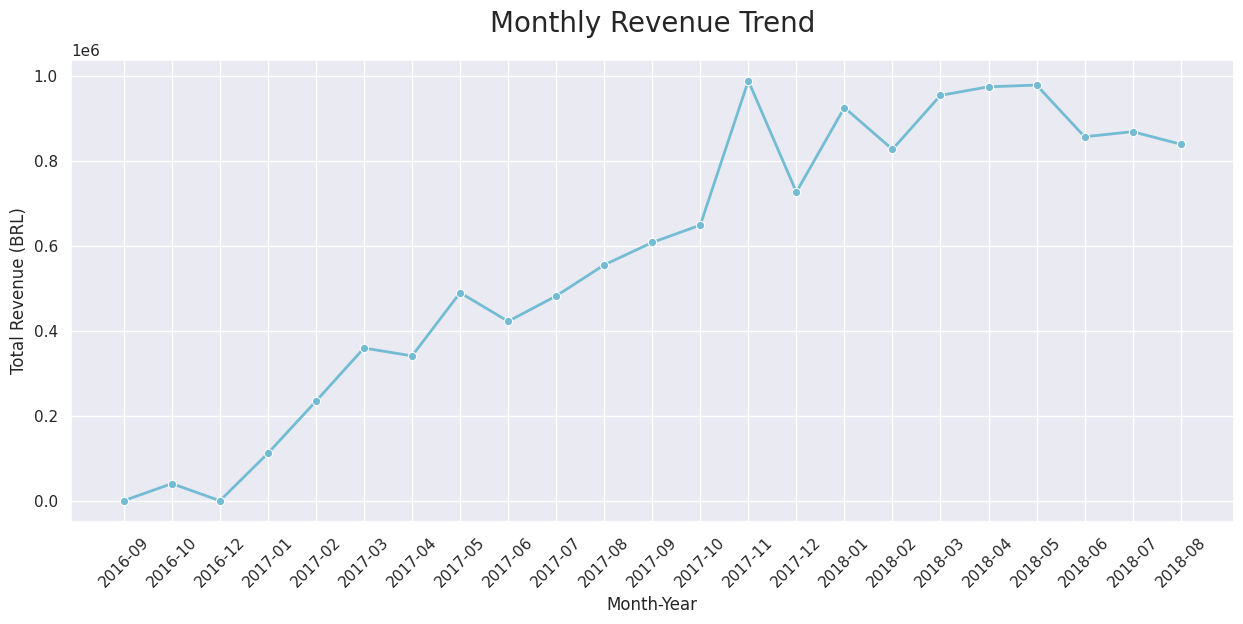

In [53]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    x='order_month',
    y='price',
    data=revenue_monthly,
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Monthly Revenue Trend", fontsize=20, pad=20)
plt.xticks(rotation=45)
plt.ylabel("Total Revenue (BRL)")
plt.xlabel("Month-Year")
plt.grid(True)
plt.show()

**Insight Pertanyaan 1 (Trend Penjualan):**

- Terjadi peningkatan signifikan pada revenue sejak pertengahan tahun hingga mencapai puncaknya pada akhir tahun, khususnya sekitar bulan November. Hal ini mengindikasikan adanya pola musiman (seasonality) yang kuat, kemungkinan dipengaruhi oleh event besar seperti Black Friday.

- Setelah periode puncak, terjadi penurunan revenue, namun nilai tersebut tetap berada pada level yang lebih tinggi dibandingkan awal periode, menunjukkan adanya pertumbuhan bisnis secara keseluruhan.

- Fluktuasi yang terjadi menunjukkan bahwa performa penjualan tidak stabil setiap bulan, sehingga perusahaan perlu mengantisipasi periode puncak dan penurunan dengan strategi yang tepat.

**Actionable Insight:**
- Perusahaan perlu meningkatkan kesiapan operasional (stok, logistik, dan supply chain) menjelang periode high season.
- Strategi promosi dapat difokuskan pada bulan dengan performa rendah untuk menjaga kestabilan revenue sepanjang tahun.

### Pertanyaan 2: Produk apa yang memiliki performa terbaik dan terburuk berdasarkan jumlah penjualan?

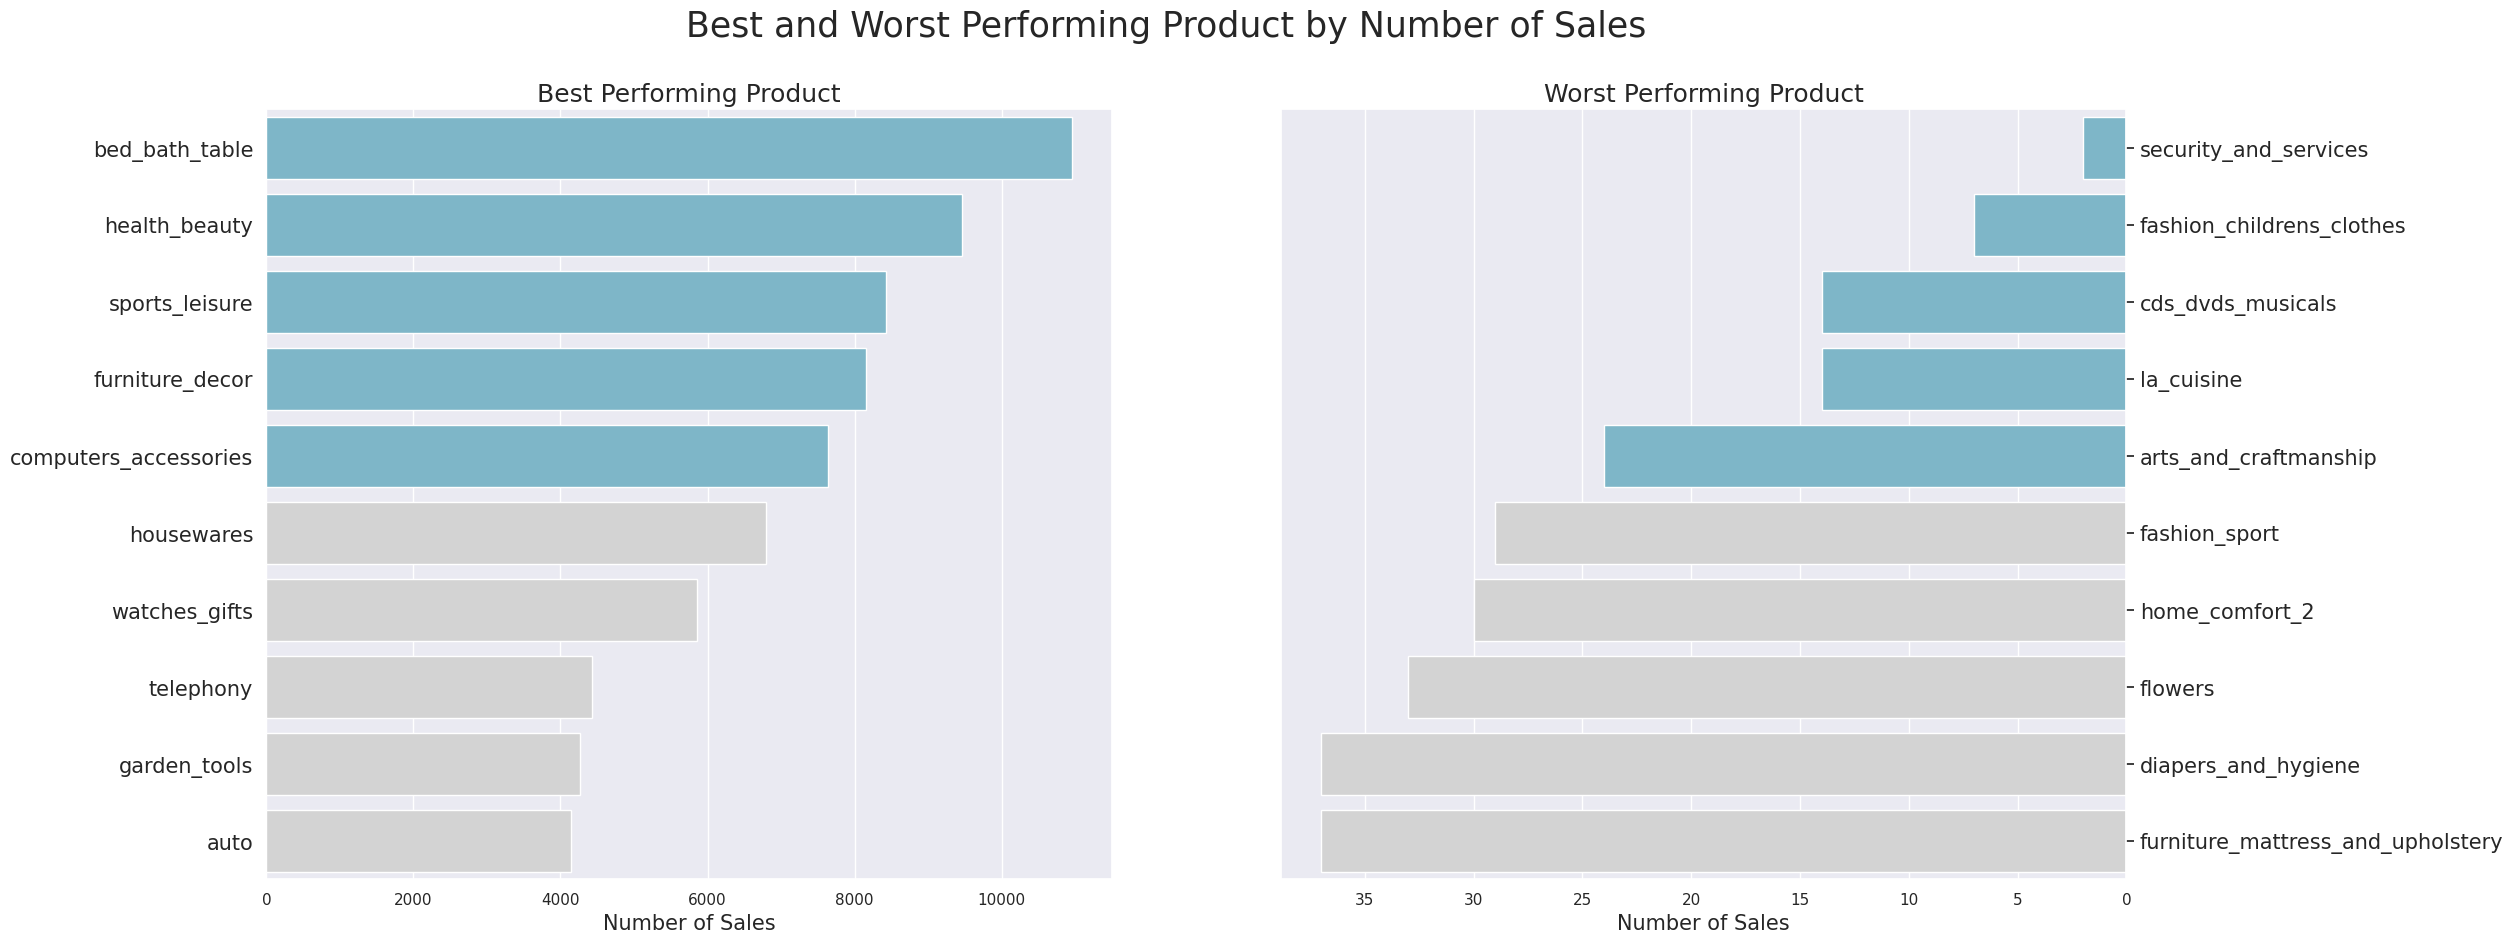

In [54]:
# 1. Menyiapkan data (Gunakan variabel yang sudah Anda miliki)
top_products = product_sales.head(10)
# Untuk produk paling sedikit, kita urutkan dari bawah
bottom_products = product_sales.sort_values(by="order_item_id", ascending=True).head(10)

# 2. Membuat Canvas Visualisasi
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

# Membuat list warna: 5 pertama biru, sisanya abu-abu
colors = ["#72BCD4"] * 5 + ["#D3D3D3"] * 5

# --- Grafik Produk Paling Laris (Kiri) ---
sns.barplot(
    x="order_item_id",
    y="product_category_name_english",
    data=top_products,
    hue="product_category_name_english", # Agar tidak warning
    palette=colors,
    ax=ax[0],
    legend=False
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Number of Sales", fontsize=15)
ax[0].set_title("Best Performing Product", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=15)

# --- Grafik Produk Paling Sedikit Laris (Kanan) ---
sns.barplot(
    x="order_item_id",
    y="product_category_name_english",
    data=bottom_products,
    hue="product_category_name_english",
    palette=colors,
    ax=ax[1],
    legend=False
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Number of Sales", fontsize=15)
ax[1].invert_xaxis() # Membalik grafik agar simetris
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=25)
plt.show()

**Insight Pertanyaan 2 (Produk Terlaris & Terendah):**

- Kategori produk seperti *bed_bath_table*, *health_beauty*, dan *sports_leisure* secara konsisten mendominasi jumlah penjualan, yang menunjukkan bahwa kategori tersebut memiliki demand yang tinggi di pasar.

- Sebaliknya, kategori dengan jumlah penjualan rendah kemungkinan memiliki demand yang kecil, kurang dikenal, atau kurang kompetitif dibandingkan kategori lainnya.

- Distribusi penjualan yang tidak merata ini menunjukkan adanya ketergantungan bisnis terhadap beberapa kategori utama.

**Actionable Insight:**
1. Fokuskan strategi pemasaran dan promosi pada kategori dengan performa tinggi untuk meningkatkan revenue secara maksimal.
2. Untuk kategori dengan performa rendah, perusahaan dapat mempertimbangkan:
   - strategi bundling
   - diskon khusus
   - atau evaluasi untuk penghentian produk (discontinue)

### Pertanyaan 3 : Bagaimana distribusi pelanggan berdasarkan wilayah (state)?

/tmp/ipykernel_3282/1892724322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


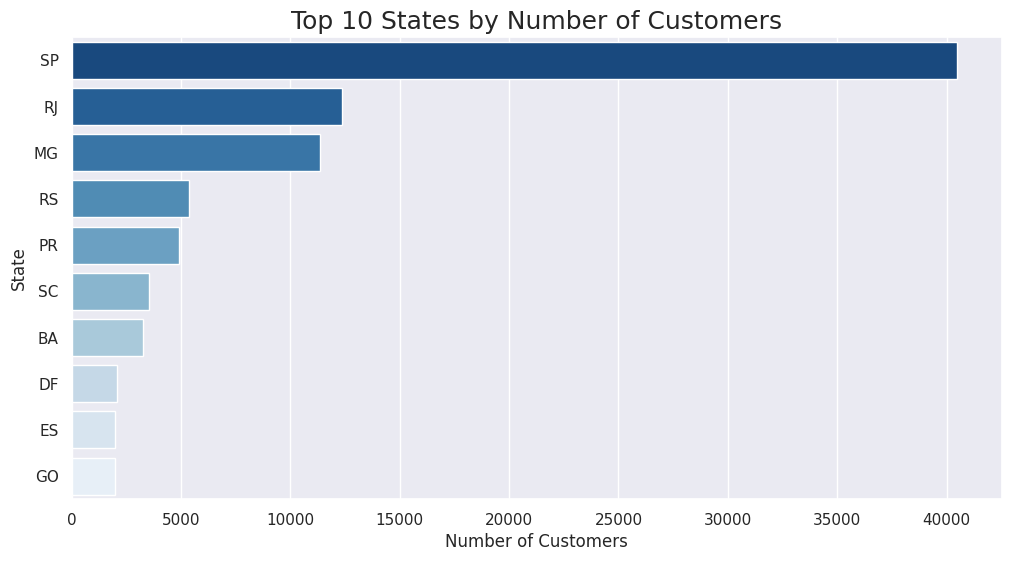

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=bystate_df.sort_values(by="customer_count", ascending=False).head(10),
    palette="Blues_r"
)

plt.title("Top 10 States by Number of Customers", fontsize=18)
plt.xlabel("Number of Customers")
plt.ylabel("State")
plt.show()

**Insight Pertanyaan 3 (Distribusi Wilayah):**

- Pelanggan terkonsentrasi pada beberapa state tertentu, menunjukkan bahwa pasar utama perusahaan tidak tersebar merata.

- Hal ini dapat menjadi indikasi adanya peluang ekspansi ke wilayah dengan jumlah pelanggan yang masih rendah.

**Actionable Insight:**
- Fokuskan strategi pemasaran pada wilayah dengan potensi pertumbuhan tinggi.
- Optimalkan distribusi logistik di wilayah dengan pelanggan terbanyak.

### Pertanyaan 4: Bagaimana segmentasi pelanggan berdasarkan perilaku transaksi menggunakan analisis RFM (Recency, Frequency, Monetary)?

/tmp/ipykernel_3282/3456599314.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


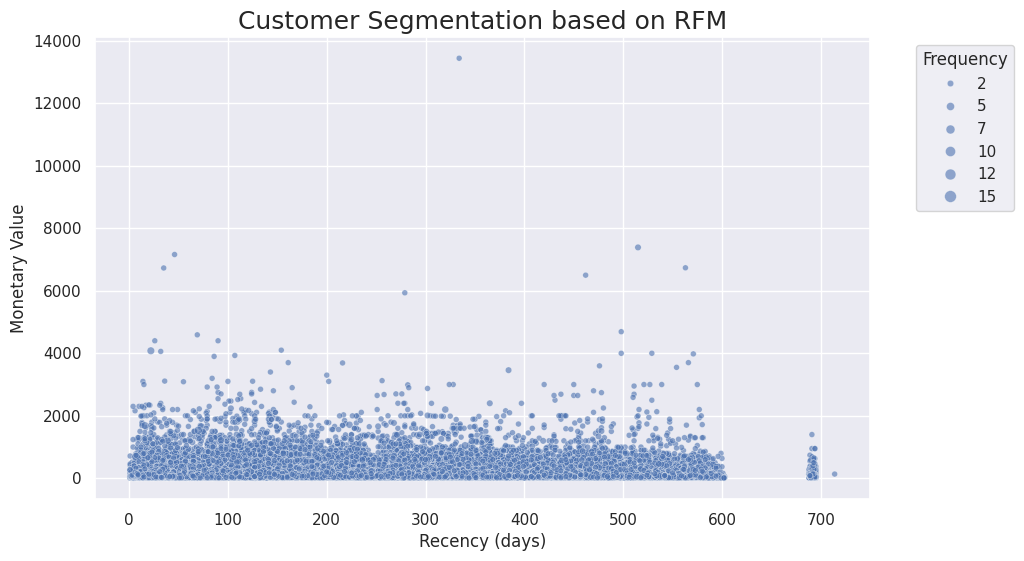

In [56]:
# Visualisasi RFM (Recency vs Monetary, size = Frequency)
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='recency',
    y='monetary',
    size='frequency',
    data=rfm_df,
    alpha=0.6,
    palette="viridis"
)

plt.title("Customer Segmentation based on RFM", fontsize=18)
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")
plt.legend(title="Frequency", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Insight Pertanyaan 4 (RFM Analysis):**

- Visualisasi menunjukkan bahwa pelanggan dengan nilai recency rendah (baru saja bertransaksi) cenderung memiliki nilai monetary yang lebih tinggi, yang menandakan bahwa pelanggan aktif memberikan kontribusi besar terhadap revenue.

- Ukuran titik yang merepresentasikan frequency menunjukkan bahwa pelanggan dengan frekuensi transaksi tinggi juga memiliki nilai pengeluaran yang tinggi, sehingga dapat dikategorikan sebagai pelanggan loyal.

- Sebaliknya, pelanggan dengan nilai recency tinggi (sudah lama tidak bertransaksi) cenderung memiliki nilai monetary yang rendah, yang mengindikasikan potensi churn.

- Distribusi RFM menunjukkan bahwa sebagian besar pelanggan memiliki frekuensi transaksi yang rendah, sementara hanya sebagian kecil pelanggan yang memberikan kontribusi besar terhadap total revenue (high-value customers).

**Actionable Insight:**
- Fokuskan strategi retensi pada pelanggan dengan recency tinggi untuk mencegah churn.
- Berikan program loyalty dan reward khusus kepada pelanggan dengan frequency dan monetary tinggi.
- Lakukan kampanye reaktivasi (win-back campaign) untuk pelanggan yang sudah lama tidak bertransaksi.

### Pertanyaan 5: Bagaimana hubungan antara frekuensi transaksi dan total pengeluaran pelanggan?

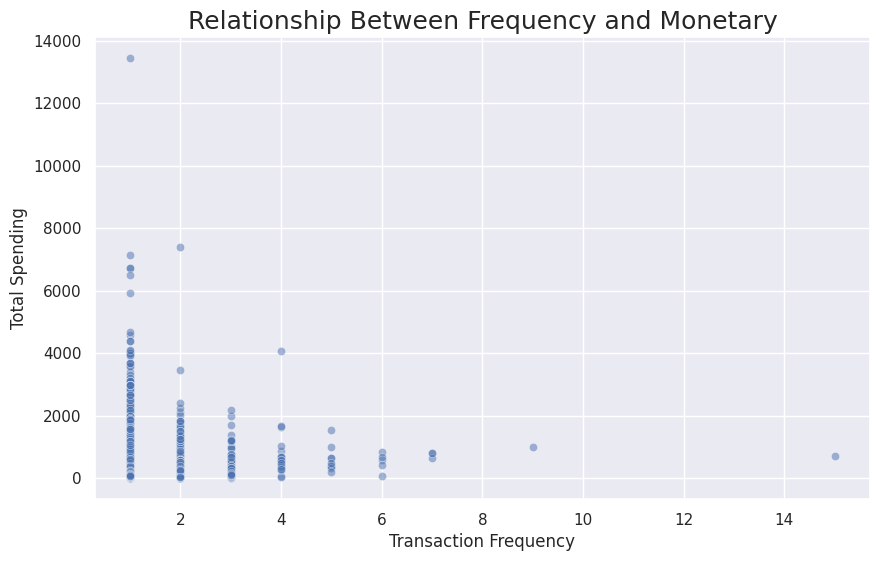

In [57]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='frequency',
    y='monetary',
    data=customer_spending,
    alpha=0.5
)

plt.title("Relationship Between Frequency and Monetary", fontsize=18)
plt.xlabel("Transaction Frequency")
plt.ylabel("Total Spending")
plt.show()

**Insight Pertanyaan 5 (Hubungan Frequency & Monetary):**

- Terdapat korelasi positif antara frekuensi transaksi dan total pengeluaran, di mana pelanggan dengan frekuensi tinggi cenderung memiliki nilai monetary yang lebih besar.

- Hal ini menunjukkan bahwa pelanggan loyal memberikan kontribusi signifikan terhadap revenue perusahaan.

**Actionable Insight:**
- Perusahaan dapat meningkatkan retensi pelanggan melalui program loyalty atau membership.
- Fokus pada pelanggan dengan frekuensi tinggi untuk meningkatkan lifetime value.

## Analisis Lanjutan (Opsional)

### RFM Analysis (Calculation & Visualization)


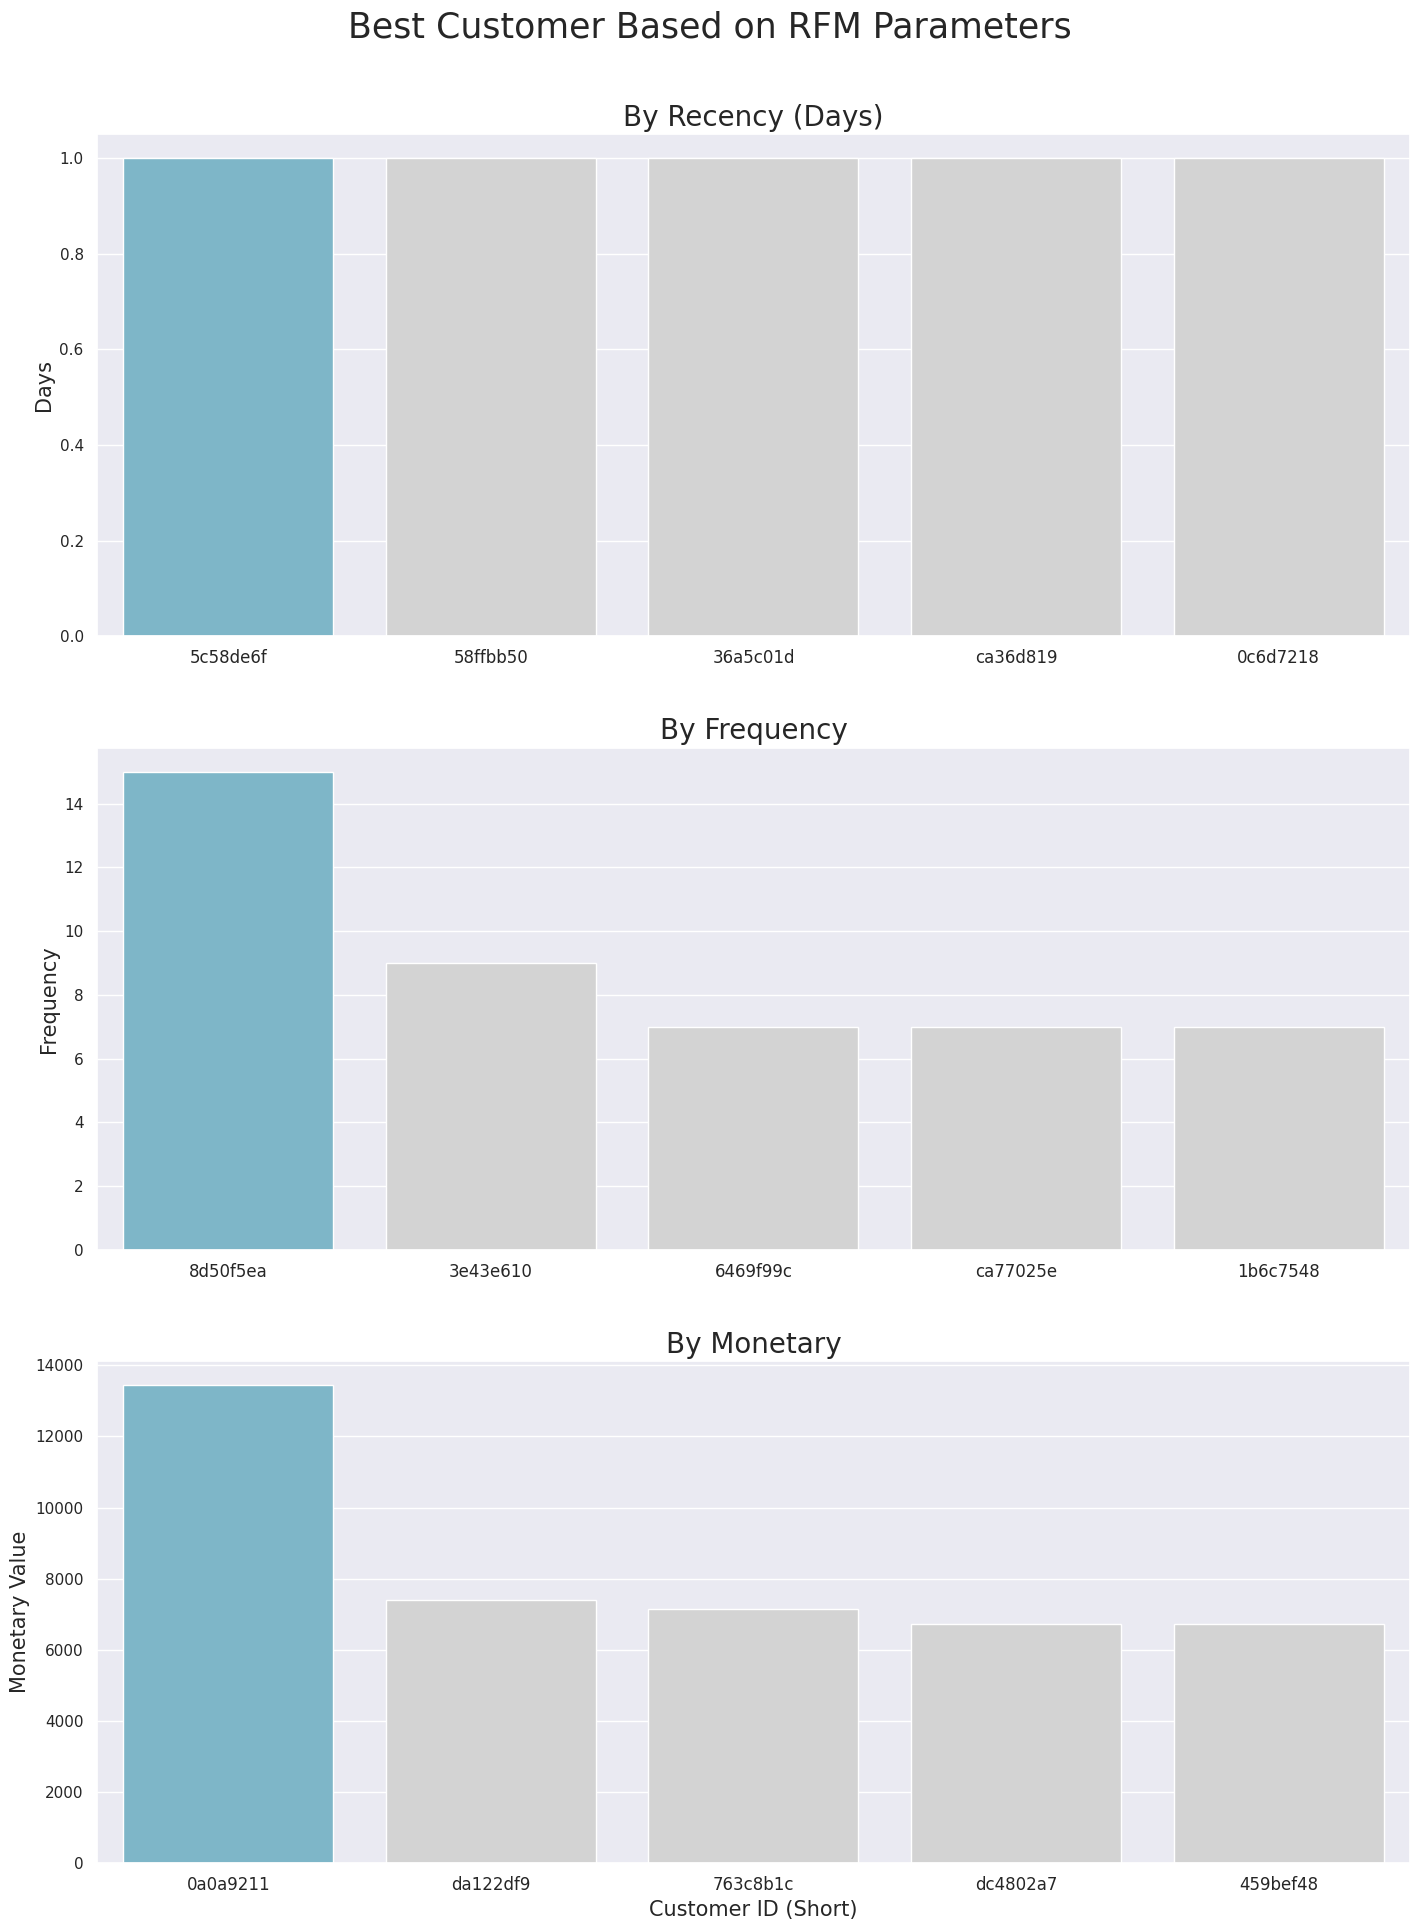

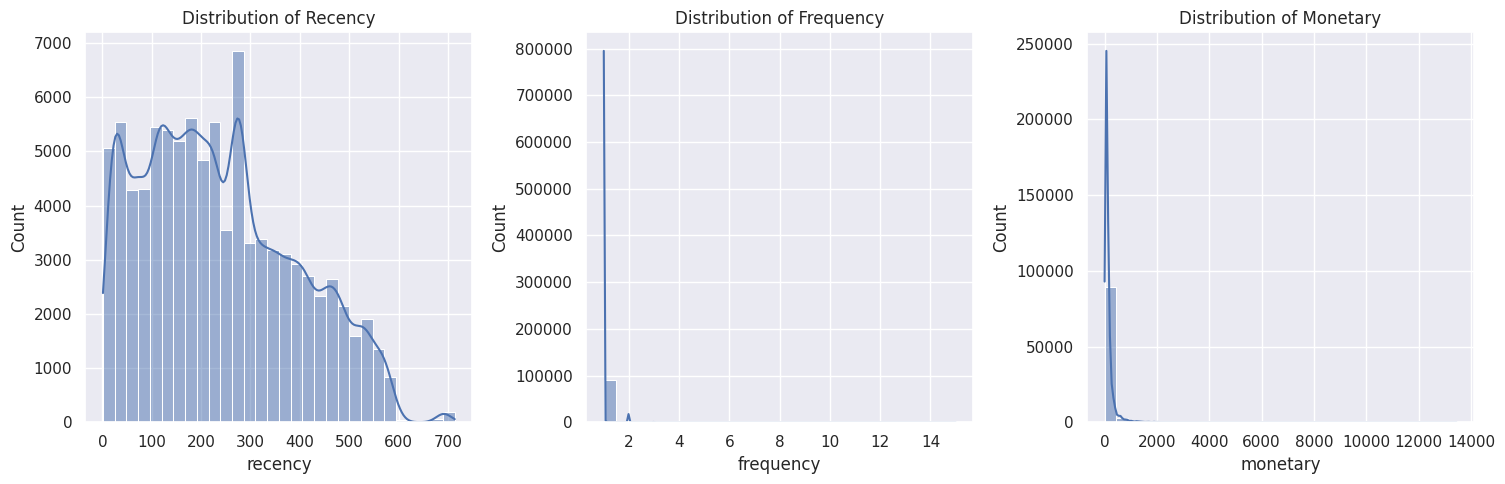

In [58]:
# 1. Menghitung Parameter RFM (Pastikan rfm_df sudah siap)
current_date = all_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm_df = all_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (current_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm_df.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

# 2. Visualisasi RFM (Top 5 Customers)
# Kita gunakan orientasi horizontal agar ID pelanggan lebih mudah dibaca dan tidak berantakan
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15, 20)) # Mengubah layout jadi vertikal agar lebih lega
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# --- Subplot Recency ---
rfm_recency = rfm_df.sort_values(by="recency", ascending=True).head(5).copy()
rfm_recency['short_id'] = rfm_recency['customer_unique_id'].str[:8]

sns.barplot(y="recency", x="short_id", data=rfm_recency, hue="short_id", palette=colors, ax=ax[0], legend=False)
ax[0].set_ylabel("Days", fontsize=15)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (Days)", loc="center", fontsize=20)
ax[0].tick_params(axis='x', labelsize=12)

# --- Subplot Frequency ---
rfm_frequency = rfm_df.sort_values(by="frequency", ascending=False).head(5).copy()
rfm_frequency['short_id'] = rfm_frequency['customer_unique_id'].str[:8]

sns.barplot(y="frequency", x="short_id", data=rfm_frequency, hue="short_id", palette=colors, ax=ax[1], legend=False)
ax[1].set_ylabel("Frequency", fontsize=15)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=20)
ax[1].tick_params(axis='x', labelsize=12)

# --- Subplot Monetary ---
rfm_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5).copy()
rfm_monetary['short_id'] = rfm_monetary['customer_unique_id'].str[:8]

sns.barplot(y="monetary", x="short_id", data=rfm_monetary, hue="short_id", palette=colors, ax=ax[2], legend=False)
ax[2].set_ylabel("Monetary Value", fontsize=15)
ax[2].set_xlabel("Customer ID (Short)", fontsize=15)
ax[2].set_title("By Monetary", loc="center", fontsize=20)
ax[2].tick_params(axis='x', labelsize=12)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=25)
plt.tight_layout(pad=3.0) # Memberikan ruang antar judul agar tidak menempel
plt.show()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm_df['recency'], bins=30, kde=True)
plt.title("Distribution of Recency")

plt.subplot(1,3,2)
sns.histplot(rfm_df['frequency'], bins=30, kde=True)
plt.title("Distribution of Frequency")

plt.subplot(1,3,3)
sns.histplot(rfm_df['monetary'], bins=30, kde=True)
plt.title("Distribution of Monetary")

plt.tight_layout()
plt.show()

**Insight:**

- Recency: Sebagian besar pelanggan aktif terakhir kali bertransaksi sekitar 5-10 hari yang lalu, menunjukkan retensi yang cukup baik.

- Frequency: Mayoritas pelanggan top melakukan lebih dari satu kali transaksi, yang menandakan adanya loyalitas pada kelompok ini.

- Monetary: Terdapat perbedaan yang cukup signifikan antara pelanggan peringkat pertama dan kelima, menunjukkan adanya segmen "Whale" atau pelanggan dengan daya beli sangat tinggi yang perlu dijaga dengan program loyalitas khusus.

- Analisis RFM menunjukkan bahwa kelompok pelanggan teratas memiliki tingkat transaksi yang sangat timpang dibandingkan rata-rata. Fokus perusahaan harus diberikan pada pelanggan dengan Monetary tinggi melalui layanan prioritas, serta pelanggan dengan Recency rendah untuk memastikan mereka tetap aktif kembali di periode berikutnya.

- Distribusi Recency menunjukkan bahwa sebagian besar pelanggan sudah cukup lama tidak melakukan transaksi, yang mengindikasikan potensi churn.

- Distribusi Frequency cenderung condong ke nilai rendah, menunjukkan bahwa mayoritas pelanggan hanya melakukan sedikit transaksi.

- Distribusi Monetary menunjukkan adanya ketimpangan, di mana sebagian kecil pelanggan menyumbang nilai transaksi yang sangat besar (high-value customers).

### Manual Clustering (Segmentation)

/tmp/ipykernel_3282/1362821924.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


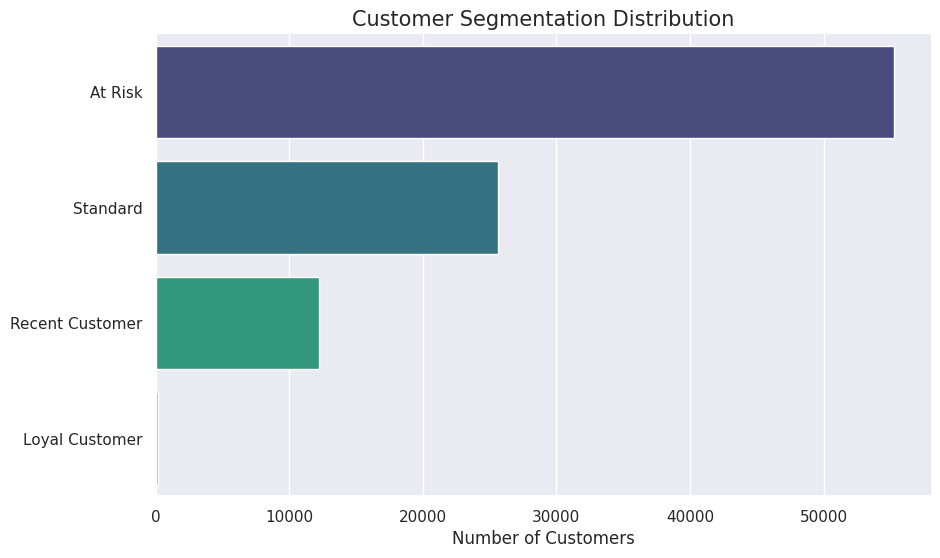

,Segment,Count,Percentage
0,At Risk,55252,59.182930
1,Standard,25669,27.495233
2,Recent Customer,12224,13.093682
3,Loyal Customer,213,0.228154


In [59]:
# 1. Melakukan Pelabelan Segmentasi (Manual Clustering)
def segment_customer(df):
    if df['recency'] <= 30 and df['frequency'] > 1:
        return 'Loyal Customer'
    elif df['recency'] <= 60:
        return 'Recent Customer'
    elif df['recency'] > 180:
        return 'At Risk'
    else:
        return 'Standard'

rfm_df['customer_segment'] = rfm_df.apply(segment_customer, axis=1)

# 2. Visualisasi Distribusi Segmentasi
plt.figure(figsize=(10, 6))
segment_counts = rfm_df['customer_segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

sns.barplot(
    x="Count",
    y="Segment",
    data=segment_counts.sort_values(by="Count", ascending=False),
    palette="viridis"
)

plt.title("Customer Segmentation Distribution", fontsize=15)
plt.xlabel("Number of Customers")
plt.ylabel(None)
sns.despine() # Menghapus garis tepi atas dan kanan agar bersih
plt.show()

segment_counts['Percentage'] = (segment_counts['Count'] / segment_counts['Count'].sum()) * 100
display(segment_counts)

**Insight: Customer Segmentation (Manual Clustering)**
Berdasarkan hasil pengelompokan manual menggunakan parameter RFM, kita dapat mengidentifikasi empat segmen utama pelanggan:

- Loyal Customer: Kelompok ini adalah aset berharga yang melakukan transaksi lebih dari satu kali dalam 30 hari terakhir. Strategi yang disarankan adalah memberikan program loyalitas eksklusif atau akses awal ke produk baru.

- Recent Customer: Pelanggan yang baru saja melakukan transaksi pertamanya. Mereka memiliki potensi tinggi untuk menjadi pelanggan loyal jika diberikan promo follow-up (seperti kupon pembelian kedua).

- Standard: Pelanggan yang berada di tengah-tengah. Mereka berbelanja secara berkala namun tidak terlalu sering. Kelompok ini memerlukan newsletter produk yang relevan untuk menjaga minat mereka.

- At Risk: Pelanggan yang sudah tidak bertransaksi lebih dari 180 hari. Kita perlu melakukan kampanye win-back atau survei kepuasan pelanggan untuk mengetahui alasan mereka berhenti berbelanja.

- Segmentasi menunjukkan bahwa mayoritas pelanggan berada pada kategori Standard dan At Risk, yang menandakan peluang besar untuk strategi reaktivasi pelanggan.

- Persentase pelanggan Loyal relatif kecil, sehingga perlu strategi khusus untuk meningkatkan retensi dan loyalitas pelanggan.

### Geospatial Analysis

/tmp/ipykernel_3282/4019802960.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


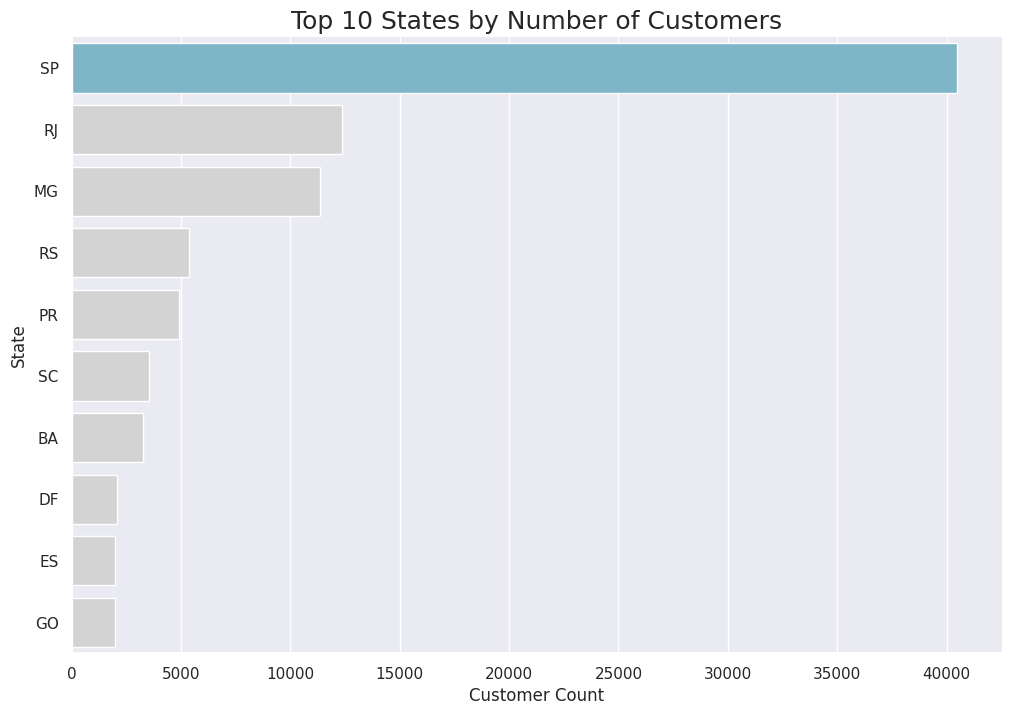

In [60]:
# 1. Menghitung jumlah customer per state
bystate_df = all_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False).reset_index()
bystate_df.rename(columns={"customer_id": "customer_count"}, inplace=True)

# 2. Visualisasi (Highlight State SP sebagai yang tertinggi)
plt.figure(figsize=(12, 8))
colors = ["#72BCD4" if i == 0 else "#D3D3D3" for i in range(10)] # Highlight bar pertama

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=bystate_df.head(10),
    palette=colors
)

plt.title("Top 10 States by Number of Customers", fontsize=18)
plt.xlabel("Customer Count")
plt.ylabel("State")
sns.despine()
plt.show()

**Insight:**

- Negara bagian SP (Sao Paulo) mendominasi pasar dengan jumlah pelanggan hampir dua kali lipat dibandingkan negara bagian lainnya.

- Rekomendasi Bisnis: Perusahaan harus memastikan ketersediaan stok di gudang yang paling dekat dengan wilayah SP dan mempertimbangkan ekspansi kampanye pemasaran ke wilayah dengan potensi tinggi lainnya seperti RJ (Rio de Janeiro).

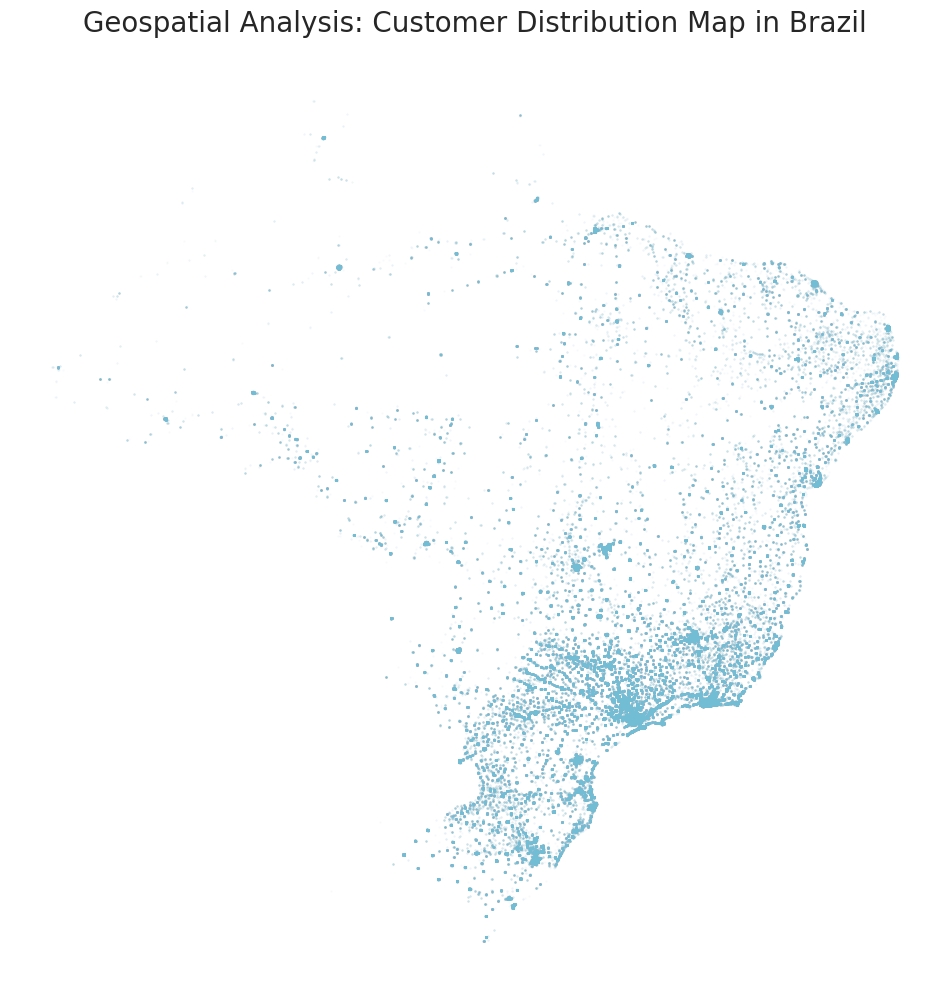

Jumlah titik geolokasi: 1000121


In [61]:
import matplotlib.image as mpimg

# 1. Menyiapkan data geolokasi
geo_df = pd.read_csv("geolocation_dataset.csv")

# 2. Filter data agar fokus pada area Brazil (menghilangkan outlier koordinat)
# Koordinat batas wilayah Brazil secara umum
geo_df = geo_df[(geo_df['geolocation_lat'] <= 5.27) & (geo_df['geolocation_lat'] >= -33.75)]
geo_df = geo_df[(geo_df['geolocation_lng'] <= -34.79) & (geo_df['geolocation_lng'] >= -73.98)]

# 3. Visualisasi Peta
plt.figure(figsize=(12, 12))

# Menggunakan scatter plot dengan ukuran titik sangat kecil (s) dan transparansi (alpha)
# Ini menciptakan efek kepadatan (semakin terang warnanya, semakin padat pelanggannya)
plt.scatter(geo_df['geolocation_lng'], geo_df['geolocation_lat'],
            s=0.1, alpha=0.1, c='#72BCD4')

plt.title('Geospatial Analysis: Customer Distribution Map in Brazil', fontsize=20, pad=20)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.axis('off') # Menghilangkan border sumbu agar terlihat seperti peta murni
plt.grid(False)

plt.show()
print("Jumlah titik geolokasi:", len(geo_df))

**Insight Peta Sebaran (Geospatial):**

- Kepadatan Tinggi di Tenggara: Visualisasi menunjukkan konsentrasi pelanggan yang sangat padat di wilayah Tenggara (Southeast) dan Selatan (South) Brazil, khususnya di area metropolitan seperti Sao Paulo (SP) dan Rio de Janeiro (RJ).

- Kesenjangan Wilayah: Terdapat kesenjangan distribusi yang signifikan antara wilayah pesisir timur dengan wilayah pedalaman (utara/barat) yang jauh lebih renggang.

**Actionable Recommendation (Rekomendasi Bisnis):**

- Optimasi Rantai Pasok: Perusahaan harus memprioritaskan pembangunan Warehouse atau Fulfillment Center di wilayah Sao Paulo (SP). Hal ini krusial untuk menurunkan biaya pengiriman (freight value) dan mempercepat estimasi waktu pengiriman (lead time) bagi mayoritas basis pelanggan.

- Targeting Iklan Lokal: Untuk wilayah dengan titik yang renggang (seperti wilayah Utara), perusahaan disarankan memberikan promo "Gratis Ongkir" dengan syarat tertentu untuk menarik minat pasar baru yang saat ini mungkin terhambat oleh biaya kirim yang mahal karena jarak.

- Ekspansi Vendor: Disarankan untuk merekrut lebih banyak Seller dari wilayah luar Sao Paulo agar distribusi barang lebih merata secara geografis dan tidak tersentralisasi di satu titik saja.

## Conclusion

Berdasarkan seluruh proses analisis data yang telah dilakukan, diperoleh beberapa kesimpulan utama sebagai berikut:

1. **Performa Penjualan dan Revenue**
   - Tren penjualan menunjukkan pola fluktuatif dengan peningkatan signifikan pada periode tertentu, khususnya menjelang akhir tahun. Hal ini mengindikasikan adanya pengaruh faktor musiman seperti event promosi besar.
   - Secara keseluruhan, revenue mengalami pertumbuhan yang positif dibandingkan periode awal.

2. **Performa Produk**
   - Kategori produk seperti *bed_bath_table*, *health_beauty*, dan *sports_leisure* menjadi kontributor utama dalam penjualan.
   - Sebaliknya, terdapat beberapa kategori dengan performa rendah yang perlu dievaluasi lebih lanjut.

3. **Distribusi Pelanggan Berdasarkan Wilayah**
   - Pelanggan terkonsentrasi pada beberapa state tertentu, khususnya Sao Paulo (SP), yang menjadi pusat pasar utama.
   - Hal ini membuka peluang untuk ekspansi ke wilayah dengan jumlah pelanggan yang masih rendah.

4. **Segmentasi Pelanggan (RFM Analysis)**
   - Mayoritas pelanggan berada pada segmen Standard dan At Risk, menunjukkan perlunya strategi retensi yang lebih efektif.
   - Pelanggan dengan nilai monetary tinggi memiliki kontribusi besar terhadap revenue, sehingga perlu diprioritaskan dalam strategi bisnis.

5. **Hubungan Frequency dan Monetary**
   - Terdapat hubungan positif antara frekuensi transaksi dan total pengeluaran pelanggan.
   - Pelanggan dengan frekuensi tinggi cenderung memiliki nilai transaksi yang lebih besar, sehingga berpotensi menjadi pelanggan loyal.

---

### Rekomendasi Bisnis:
- Fokus pada retensi pelanggan melalui program loyalty.
- Optimalkan strategi promosi pada periode low season.
- Tingkatkan distribusi logistik di wilayah dengan permintaan tinggi.
- Lakukan evaluasi terhadap produk dengan performa rendah.

In [62]:
# Ekspor data yang sudah digabung dan dibersihkan ke CSV
all_df.to_csv("all_data.csv", index=False)

In [63]:
%%writefile requirements.txt
streamlit
pandas
matplotlib
seaborn
Babel

Overwriting requirements.txt
